In [60]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')
df.to_csv("titanic.csv", index=False)
df = pd.read_csv("titanic.csv")

#following lines print shape, columns which all are present in dataset and their types
print(f'shape : {df.shape}')
print(f'column names: {df.columns}')
print(f'column dtype: {df.dtypes}')

#head() returns top 5 rows
print('\n Top 5:')
print(df.head())

#tail() return below 5 rows.
print('\n Tail 5:')
print(df.tail())


shape : (891, 15)
column names: Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')
column dtype: survived         int64
pclass           int64
sex             object
age            float64
sibsp            int64
parch            int64
fare           float64
embarked        object
class           object
who             object
adult_male        bool
deck            object
embark_town     object
alive           object
alone             bool
dtype: object

 Top 5:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0      

In [61]:

#Q3: missing values analysis;
print(f'\n Missing values analysis')
number_of_rows_with_missing_values = df.isna().any(axis=1).sum()
number_of_columns_with_missing_values = df.isna().any(axis=0).sum()
print(f'Total number of rows which has missing values : {number_of_rows_with_missing_values}')
print(f'Total number of columns which has missing values : {number_of_columns_with_missing_values}')

print(f'fraction_missing_values_for_rows: {number_of_rows_with_missing_values/len(df)}')
print(f'fraction_missing_values_for_columns: {number_of_columns_with_missing_values/len(df)}')




 Missing values analysis
Total number of rows which has missing values : 709
Total number of columns which has missing values : 4
fraction_missing_values_for_rows: 0.7957351290684624
fraction_missing_values_for_columns: 0.004489337822671156


In [62]:
#Q4: Memory usage
print(df.memory_usage(deep=True).sum() / 1024**2)
print(df['class'].astype('category').memory_usage(deep=True) / 1024**2)
#When the initial data frame loaded the memory usage is ~0.35MB
#When the data is categorized, the memory usage is reduced to 0.0012


0.3464937210083008
0.0012340545654296875


In [63]:


#Q5: Survaival rate

print(f'Survaival rate : {df['survived'].mean() }')

#The total survival rate is 0.38 means 38 people survived out of 100 people

Survaival rate : 0.3838383838383838


In [64]:
#Q6: Mean age by survival
print(f'mean by survived : {df.groupby('survived')['age'].mean()}')

#On the average which age group people survived and which age group people died
# Age ~30, died
# Age ~23, survived


mean by survived : survived
0    30.626179
1    28.343690
Name: age, dtype: float64


Mean survival by class : pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64
bar chart for survival.


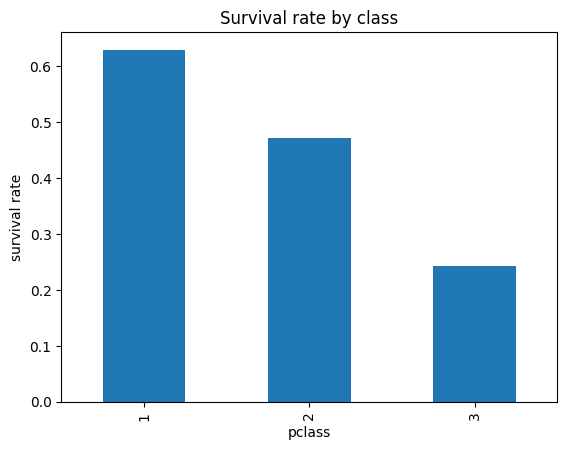

In [69]:
#Q7: Survival by class
print(f'Mean survival by class : {df.groupby('pclass')['survived'].mean()}')
#bar chart for survival.
print('bar chart for survival.')
df.groupby('pclass')['survived'].mean().plot(kind='bar', title='Survival rate by class', ylabel='survival rate')
plt.show()

#In, class-1 people - out of 100, 62 people survived.
#In, class-2 people - out of 100, 47 people survived.
#In, class-3 people - out of 100, 24 people survived.


Survival by sex
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


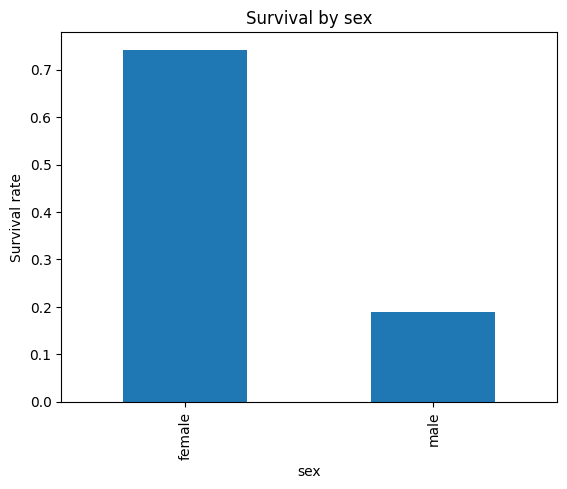

In [70]:

#Q8: Survival by sex
print('Survival by sex')
print(df.groupby('sex')['survived'].mean())
df.groupby('sex')['survived'].mean().plot(kind='bar', title='Survival by sex', ylabel='Survival rate')
plt.show()

#sex-female - out of 100 people 74 people survived
#sex-male - out of 100 people 18 people survied

Survival by class and sex
sex     pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64


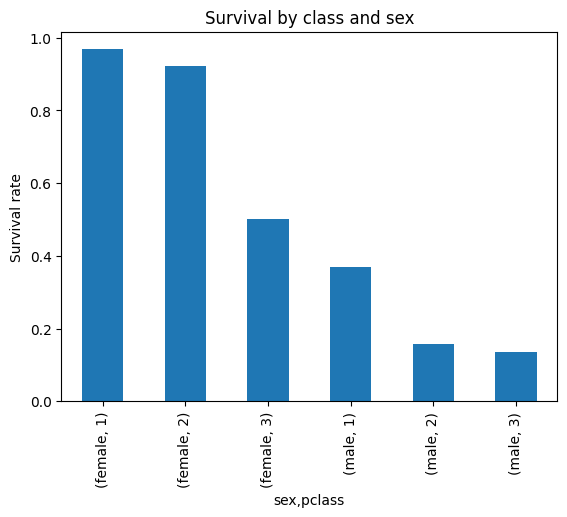

In [72]:
#Q9 : Survival by class and sex
print('Survival by class and sex')
print(df.groupby(['sex', 'pclass'])['survived'].mean())
df.groupby(['sex', 'pclass'])['survived'].mean().plot(kind='bar', title='Survival by class and sex', ylabel='Survival rate')
plt.show()
#In class-1 female ~96 people survived out of 100
#In class-2 female ~92 people survived out of 100
#In class-3 female ~50 people survived out of 100
#In class-1 male ~36 people survived out of 100
#In class-2 male ~15 people survived out of 100
#In class-3 male ~13 people survived out of 100
